#Problem 1A: Single-Year HDI Exploration



In this problem, I analyze the Human Development Index (HDI) dataset for the year 2022 to understand basic patterns, clean the data, and compute summary statistics.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This shows the first few rows of the dataset.

In [7]:
import pandas as pd

df = pd.read_csv("/content/Human_Development_Index_Dataset (2).csv", encoding="latin1")
df.head()



,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,1990,0.284,45.967,10.694796,NaN,NaN,48.397,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,1991,0.292,46.663,10.745167,NaN,NaN,49.144,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,1992,0.299,47.596,12.057433,NaN,NaN,50.320,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,1993,0.307,51.466,14.003760,NaN,NaN,52.739,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,1994,0.300,51.495,15.455554,NaN,NaN,53.544,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


Here we check number of rows, columns and column names.

In [8]:
df.shape
df.columns


Index(['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy',
       'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m',
       'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m',
       'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m',
       'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
       'gender_development', 'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons'],
      dtype='object')

In [9]:
df.dtypes


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


We take only the data for year 2022.

In [10]:
hdi_2022_df = df[df['year'] == 2022]
hdi_2022_df.head()


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568


In [11]:
hdi_2022_df.shape


(206, 30)

In [12]:
hdi_2022_df = hdi_2022_df.replace("–", pd.NA)
hdi_2022_df = hdi_2022_df.drop_duplicates()
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi'])


The mean and median show the average HDI value, while the standard deviation shows variation across countries.


In [13]:
hdi_2022_df['hdi'].mean()
hdi_2022_df['hdi'].median()
hdi_2022_df['hdi'].std()



0.15302880386427825

In [14]:
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.8]
high_hdi.sort_values(by='gross_inc_percap', ascending=False).head(10)


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
3332,3333,LIE,Liechtenstein,2022,0.942,84.656,0.039327,0.924163,0.974295,86.129,...,0.949,NaN,NaN,NaN,28.000000,72.000000,52.79,67.26,3.736776,NaN
4718,4719,QAT,Qatar,2022,0.875,81.559,2.695122,0.892561,0.869100,83.101,...,1.027,0.212,81.832741,71.417976,4.444444,95.555556,61.73,95.33,39.884274,63.5912
5213,5214,SGP,Singapore,2022,0.949,84.133,5.975689,0.945325,0.954078,86.295,...,0.991,0.036,80.464020,85.932037,29.126214,70.873786,63.37,77.00,9.397481,43.1508
2705,2706,IRL,Ireland,2022,0.950,82.716,5.023109,0.942838,0.951392,84.412,...,0.991,0.072,88.585639,86.417415,27.397260,72.602740,59.40,70.51,7.529751,26.3467
3398,3399,LUX,Luxembourg,2022,0.927,82.591,0.647599,0.920482,0.927311,84.770,...,0.993,0.043,96.579350,89.328283,33.333333,66.666667,57.99,65.09,13.185395,49.1903
6104,6105,ARE,United Arab Emirates,2022,0.937,79.196,9.441128,0.922940,0.936027,81.412,...,0.986,0.035,82.029137,86.145172,50.000000,50.000000,55.32,89.45,25.333276,28.1632
5609,5610,CHE,Switzerland,2022,0.967,84.255,8.740472,0.949369,0.977383,85.932,...,0.971,0.018,96.939726,97.517437,39.024390,60.975610,61.49,71.94,4.117550,33.5913
4322,4323,NOR,Norway,2022,0.966,83.393,5.434319,0.957148,0.970415,85.055,...,0.986,0.012,99.094031,99.274980,44.970414,55.029586,62.53,69.59,7.573541,32.0515
6170,6171,USA,United States,2022,0.927,78.203,338.289857,0.927693,0.923405,81.015,...,1.005,0.180,95.424278,95.067093,28.060264,71.939736,56.79,67.97,14.932487,29.3498
2474,2475,HKG,"Hong Kong, China (SAR)",2022,0.956,84.315,7.488865,0.942671,0.969515,86.893,...,0.972,NaN,77.866913,84.067802,NaN,NaN,52.91,64.71,4.373242,NaN


In [15]:
def hdi_category(h):
    if h < 0.55:
        return "Low"
    elif h < 0.70:
        return "Medium"
    elif h < 0.80:
        return "High"
    else:
        return "Very High"


 HDI Classification

Countries are classified into four HDI categories based on UNDP-defined thresholds. This classification helps compare development levels across countries in a standardized way.


In [16]:
hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(hdi_category)
hdi_2022_df.head()


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,HDI Category
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809,Low
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367,High
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199,High
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN,Very High
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568,Medium


In [17]:
hdi_2022_df.to_csv("HDI_category_added.csv", index=False)


The final cleaned dataset with the HDI Category column was saved as a CSV file for future use and submission.


In [18]:
hdi_1b = df[df['year'].isin([2020, 2021, 2022])]
hdi_1b.to_csv("HDI_problem1B.csv", index=False)


# Problem 1B

This graph shows HDI changes from 2020 to 2022.


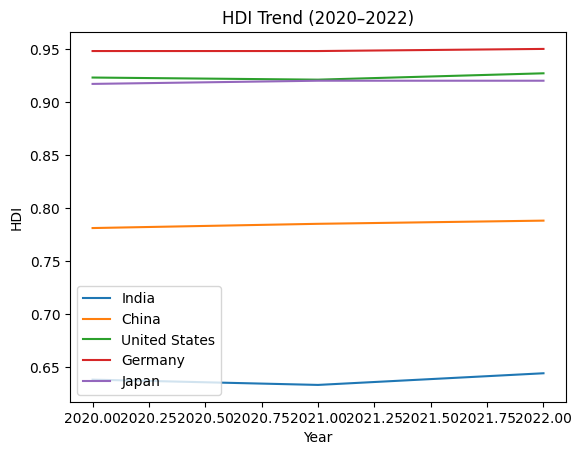

In [19]:
import matplotlib.pyplot as plt

countries = ['India', 'China', 'United States', 'Germany', 'Japan']

for c in countries:
    temp = hdi_1b[hdi_1b['country'] == c]
    plt.plot(temp['year'], temp['hdi'], label=c)

plt.xlabel("Year")
plt.ylabel("HDI")
plt.title("HDI Trend (2020–2022)")
plt.legend()
plt.show()


Most countries are in the middle to high HDI range. A few countries are very low. Overall, HDI is slowly increasing.


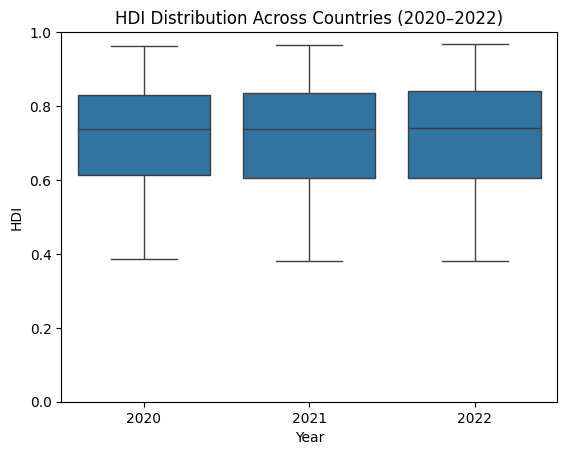

In [20]:
import seaborn as sns

sns.boxplot(data=hdi_1b, x='year', y='hdi')
plt.title("HDI Distribution Across Countries (2020–2022)")
plt.xlabel("Year")
plt.ylabel("HDI")
plt.ylim(0,1)
plt.show()


In [21]:
if 'gni' in hdi_1b.columns:
    sns.scatterplot(data=hdi_1b, x='gni', y='hdi')
    plt.title("HDI vs GNI per Capita (2020–2022)")
    plt.xlabel("GNI per Capita")
    plt.ylabel("HDI")
    plt.show()
else:
    print("GNI per Capita variable not available in this dataset.")


GNI per Capita variable not available in this dataset.


The dataset does not include a 'region' column, so the average HDI by region chart cannot be plotted.


# Problem 2

We select South Asian countries for further analysis.


In [22]:
south_asia = [
    "Afghanistan","Bangladesh","Bhutan","India",
    "Maldives","Nepal","Pakistan","Sri Lanka"
]

sa_df = df[df['country'].isin(south_asia)]
sa_df.to_csv("HDI_SouthAsia.csv", index=False)


We calculate a composite score using life expectancy and income.

In [23]:
sa_df['Composite Score'] = (
    0.3 * sa_df['life_expectancy'] +
    0.00003 * sa_df['gross_inc_percap']
)


/tmp/ipykernel_669/815327852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sa_df['Composite Score'] = (


In [24]:
sa_mean = sa_df[['life_expectancy', 'gross_inc_percap']].mean().to_frame().T
sa_mean


,life_expectancy,gross_inc_percap
0,66.161568,5453.762437


In [25]:
print(sa_mean.columns)


Index(['life_expectancy', 'gross_inc_percap'], dtype='object')


This graph shows top 5 South Asian countries by composite score.

In [26]:
top5 = (
    sa_df[['country', 'Composite Score']]
    .sort_values('Composite Score', ascending=False)
    .head(5)
)


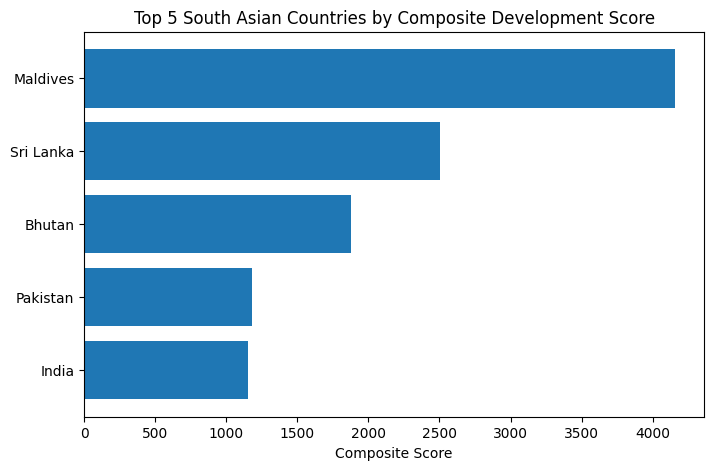

In [27]:
sa_mean = sa_df.groupby('country')[['life_expectancy', 'gross_inc_percap', 'hdi']].mean().reset_index()
sa_mean['Composite Score'] = (
    0.3 * sa_mean['life_expectancy'] +
    0.3 * sa_mean['gross_inc_percap']
)
top5 = sa_mean.sort_values(by='Composite Score', ascending=False).head(5)
top5
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top5['country'], top5['Composite Score'])
plt.xlabel('Composite Score')
plt.title('Top 5 South Asian Countries by Composite Development Score')
plt.gca().invert_yaxis()
plt.show()



In [28]:
sa_mean = sa_df.groupby('country')[['life_expectancy', 'gross_inc_percap', 'hdi','Composite Score']].mean().reset_index()

In [29]:
Q1 = sa_mean['hdi'].quantile(0.25)
Q3 = sa_mean['hdi'].quantile(0.75)
IQR = Q3 - Q1

hdi_outliers = sa_mean[
    (sa_mean['hdi'] < Q1 - 1.5 * IQR) |
    (sa_mean['hdi'] > Q3 + 1.5 * IQR)
]

hdi_outliers


,country,life_expectancy,gross_inc_percap,hdi,Composite Score


In [30]:
Q1_gni = sa_mean['gross_inc_percap'].quantile(0.25)
Q3_gni = sa_mean['gross_inc_percap'].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

gni_outliers = sa_mean[
    (sa_mean['gross_inc_percap'] < Q1_gni - 1.5 * IQR_gni) |
    (sa_mean['gross_inc_percap'] > Q3_gni + 1.5 * IQR_gni)
]

gni_outliers


,country,life_expectancy,gross_inc_percap,hdi,Composite Score
4,Maldives,74.137636,13773.371285,0.6825,22.654492


This plot shows relationship between HDI and other indicators.

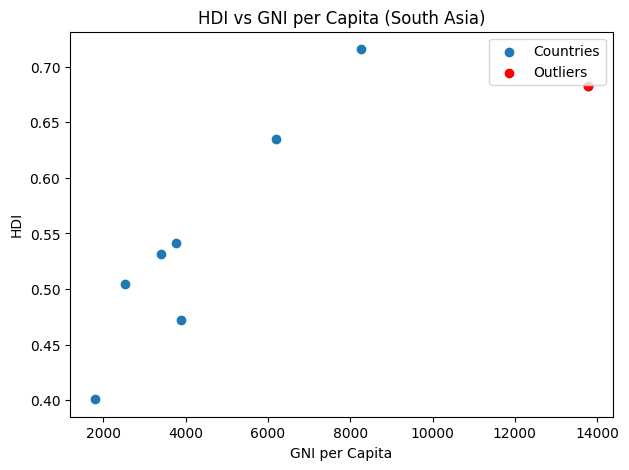

In [31]:
plt.figure(figsize=(7,5))
plt.scatter(sa_mean['gross_inc_percap'], sa_mean['hdi'], label='Countries')
plt.scatter(
    gni_outliers['gross_inc_percap'],
    gni_outliers['hdi'],
    color='red',
    label='Outliers'
)

plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('HDI vs GNI per Capita (South Asia)')
plt.legend()
plt.show()

Here we identify outliers using the IQR method.

In [32]:
sa_mean['HDI_Gap'] = sa_mean['hdi'].max() - sa_mean['hdi']
sa_mean


,country,life_expectancy,gross_inc_percap,hdi,Composite Score,HDI_Gap
0,Afghanistan,57.625909,1793.888801,0.401030,17.341589,0.314576
1,Bangladesh,66.255727,3409.021713,0.531303,19.978989,0.184303
2,Bhutan,65.500455,6195.571443,0.634538,19.836004,0.081068
3,India,65.080970,3771.922831,0.541485,19.637449,0.174121
4,Maldives,74.137636,13773.371285,0.682500,22.654492,0.033106
5,Nepal,64.416061,2532.948214,0.504242,19.400807,0.211364
6,Pakistan,63.321758,3884.286076,0.472545,19.113056,0.243061
7,Sri Lanka,72.954030,8269.089133,0.715606,22.134282,0.000000


In [33]:
gap_top5 = sa_mean.sort_values('HDI_Gap', ascending=False).head(5)
gap_top5


,country,life_expectancy,gross_inc_percap,hdi,Composite Score,HDI_Gap
0,Afghanistan,57.625909,1793.888801,0.401030,17.341589,0.314576
6,Pakistan,63.321758,3884.286076,0.472545,19.113056,0.243061
5,Nepal,64.416061,2532.948214,0.504242,19.400807,0.211364
1,Bangladesh,66.255727,3409.021713,0.531303,19.978989,0.184303
3,India,65.080970,3771.922831,0.541485,19.637449,0.174121


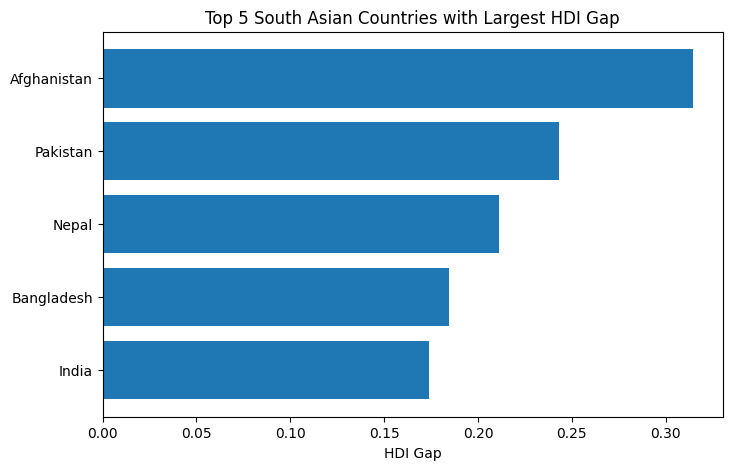

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(gap_top5['country'], gap_top5['HDI_Gap'])
plt.xlabel('HDI Gap')
plt.title('Top 5 South Asian Countries with Largest HDI Gap')
plt.gca().invert_yaxis()
plt.show()


# Problem 3

We compare HDI and related indicators between South Asia and Middle East.


In [35]:
south_asia = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

middle_east = [
    "Bahrain", "Iran", "Iraq", "Israel", "Jordan",
    "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
    "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"
]


A new column called 'Region' is added to each dataset to clearly label the region of each country.


In [36]:
def assign_region(country):
    if country in south_asia:
        return "South Asia"
    elif country in middle_east:
        return "Middle East"
    else:
        return "Other"

df['Region'] = df['country'].apply(assign_region)


In [37]:
df[['country', 'Region']].drop_duplicates().head(15)

,country,Region
0,Afghanistan,South Asia
33,Albania,Other
66,Algeria,Other
99,Andorra,Other
132,Angola,Other
165,Antigua and Barbuda,Other
198,Argentina,Other
231,Armenia,Other
264,Australia,Other
297,Austria,Other


In [38]:
sa_df = df[df['country'].isin(south_asia)]
me_df = df[df['country'].isin(middle_east)]


The dataset is filtered to create separate dataframes for South Asia and the Middle East using the selected countries.


In [39]:
sa_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
me_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)


The South Asia and Middle East datasets are saved as CSV files for further analysis and submission.


In [40]:
stats = pd.DataFrame({
    "Region": ["South Asia", "Middle East"],
    "Mean HDI": [sa_df['hdi'].mean(), me_df['hdi'].mean()],
    "Std HDI": [sa_df['hdi'].std(), me_df['hdi'].std()]
})

stats


,Region,Mean HDI,Std HDI
0,South Asia,0.551649,0.119752
1,Middle East,0.739104,0.129482


The mean HDI shows the average development level of each region, while the standard deviation shows how much HDI varies within each region.


In [41]:
sa_top = sa_df.sort_values('hdi', ascending=False).head(3)
sa_bottom = sa_df.sort_values('hdi').head(3)

me_top = me_df.sort_values('hdi', ascending=False).head(3)
me_bottom = me_df.sort_values('hdi').head(3)


This step identifies the top three and bottom three countries in each region based on HDI values.


In [42]:
combined = pd.concat([
    sa_top.assign(Group="SA Top"),
    sa_bottom.assign(Group="SA Bottom"),
    me_top.assign(Group="ME Top"),
    me_bottom.assign(Group="ME Bottom")
])


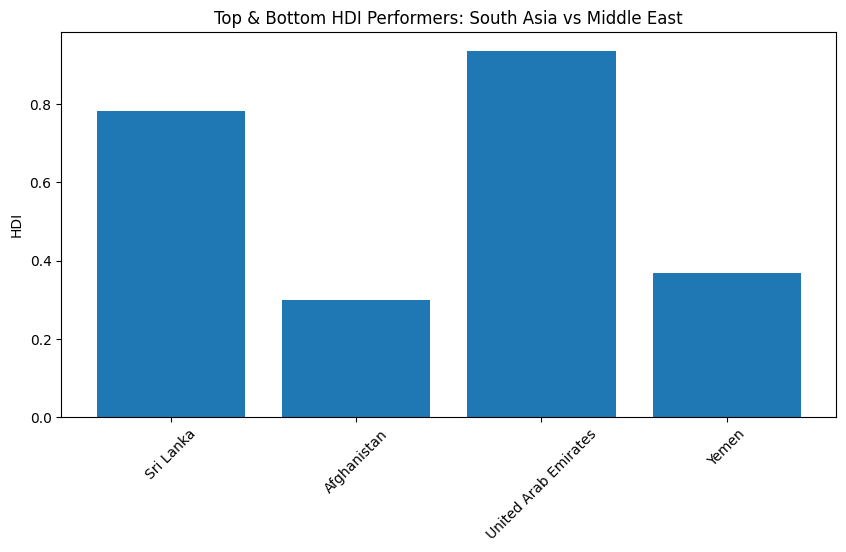

In [43]:
plt.figure(figsize=(10,5))
plt.bar(combined['country'], combined['hdi'])
plt.xticks(rotation=45)
plt.ylabel("HDI")
plt.title("Top & Bottom HDI Performers: South Asia vs Middle East")
plt.show()


Interpretation:
The bar chart compares the highest and lowest HDI countries in South Asia and the Middle East. Overall, Middle Eastern countries show higher HDI values.


In [44]:
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

sa_metrics = sa_df[metrics].mean()
me_metrics = me_df[metrics].mean()

metric_df = pd.DataFrame({
    'South Asia': sa_metrics,
    'Middle East': me_metrics
})

metric_df


,South Asia,Middle East
gender_development,0.832878,0.884572
life_expectancy,66.161568,74.162970
gross_inc_percap,5453.762437,38160.698122


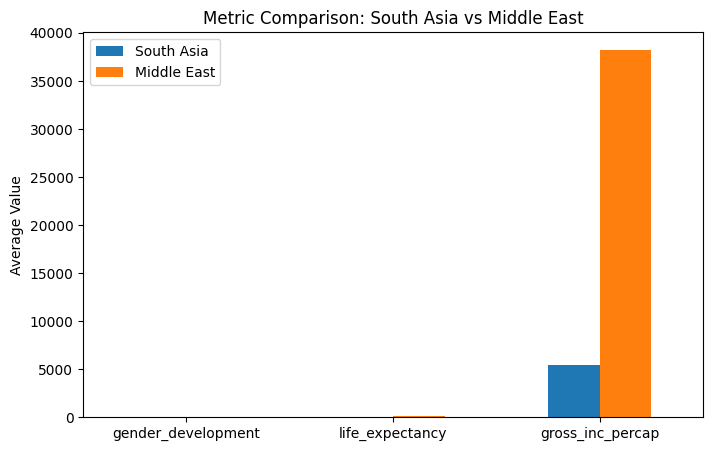

In [45]:
metric_df.plot(kind='bar', figsize=(8,5))
plt.title("Metric Comparison: South Asia vs Middle East")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


Interpretation:
This bar chart compares the average values of different development metrics between South Asia and the Middle East. The Middle East shows higher values for most metrics, especially income-related indicators.


In [46]:
range_sa = sa_df['hdi'].max() - sa_df['hdi'].min()
range_me = me_df['hdi'].max() - me_df['hdi'].min()

cv_sa = sa_df['hdi'].std() / sa_df['hdi'].mean()
cv_me = me_df['hdi'].std() / me_df['hdi'].mean()

range_sa, range_me, cv_sa, cv_me


(0.49900000000000005,
 0.5800000000000001,
 np.float64(0.21708016999742674),
 np.float64(0.1751874691636524))

In [47]:
sa_df[['hdi','gender_development','life_expectancy']].corr()


,hdi,gender_development,life_expectancy
hdi,1.000000,0.865621,0.958761
gender_development,0.865621,1.000000,0.829553
life_expectancy,0.958761,0.829553,1.000000


Correlation values show how strongly HDI is related to other development indicators in each region.


In [48]:
me_df[['hdi','gender_development','life_expectancy']].corr()


,hdi,gender_development,life_expectancy
hdi,1.000000,0.931082,0.943002
gender_development,0.931082,1.000000,0.886640
life_expectancy,0.943002,0.886640,1.000000


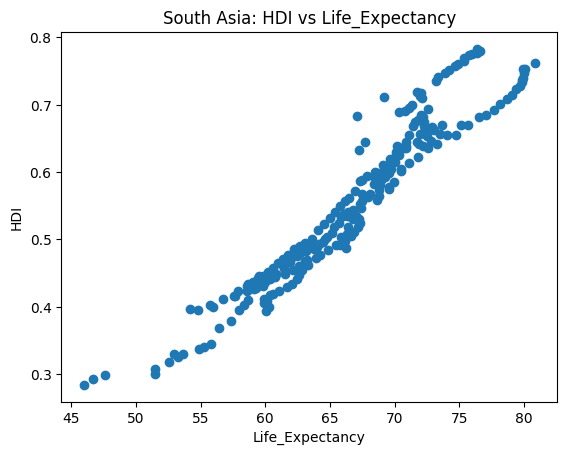

In [49]:
plt.scatter(sa_df['life_expectancy'], sa_df['hdi'])
plt.title("South Asia: HDI vs Life_Expectancy")
plt.xlabel("Life_Expectancy")
plt.ylabel("HDI")
plt.show()


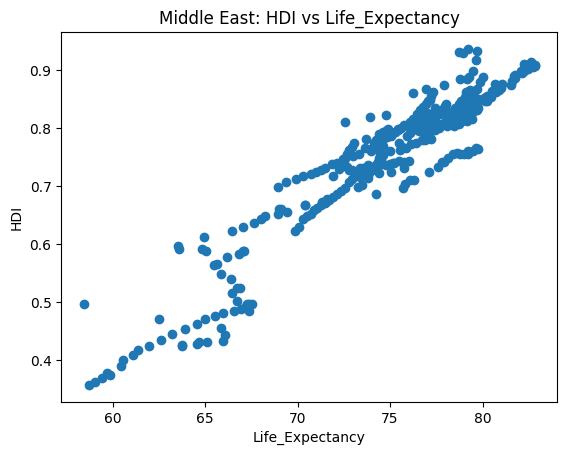

In [50]:
plt.scatter(me_df['life_expectancy'], me_df['hdi'])
plt.title("Middle East: HDI vs Life_Expectancy")
plt.xlabel("Life_Expectancy")
plt.ylabel("HDI")
plt.show()


In [51]:
Q1 = sa_df['hdi'].quantile(0.25)
Q3 = sa_df['hdi'].quantile(0.75)
IQR = Q3 - Q1

sa_outliers = sa_df[
    (sa_df['hdi'] < Q1 - 1.5*IQR) |
    (sa_df['hdi'] > Q3 + 1.5*IQR)
]

sa_outliers


,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,Region


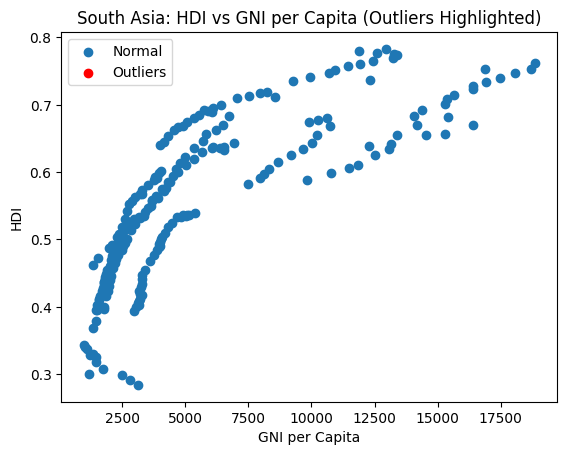

In [52]:
plt.scatter(sa_df['gross_inc_percap'], sa_df['hdi'], label='Normal')
plt.scatter(sa_outliers['gross_inc_percap'], sa_outliers['hdi'],
            color='red', label='Outliers')

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("South Asia: HDI vs GNI per Capita (Outliers Highlighted)")
plt.legend()
plt.show()


Outliers represent countries with unusually high or low HDI or income compared to others in the same region.
